#  Load packages

In [1]:
# skip reinstalling packages we already have
using Pkg

pkgs = [
    "MLJ", "MLJBase", "MLJModels", "MLJEnsembles", "MLJLinearModels",
    "DecisionTree", "MLJDecisionTreeInterface", "NaiveBayes", 
    "MLJNaiveBayesInterface", "EvoTrees", "CategoricalArrays", "Random",
    "LIBSVM", "MLJLIBSVMInterface", "Plots", "MLJModelInterface",
    "CSV", "DataFrames", "UrlDownload", "XGBoost","MultivariateStats","PrettyTables"
]

# Filter out packages already installed
missing_pkgs = filter(pkg -> !(pkg in keys(Pkg.project().dependencies)), pkgs)

if !isempty(missing_pkgs)
    println("Installing missing packages: ", missing_pkgs)
    Pkg.add(missing_pkgs)
else
    println(" All required packages are already installed.")
end


Installing missing packages: ["PrettyTables"]


    Updating registry at `C:\Users\gianp\.julia\registries\General.toml`
   Resolving package versions...
    Updating `C:\Users\gianp\.julia\environments\v1.11\Project.toml`
⌅ [08abe8d2] + PrettyTables v2.4.0
  No Changes to `C:\Users\gianp\.julia\environments\v1.11\Manifest.toml`


# Import packages

In [2]:
using CSV, DataFrames, Random
using Flux
using CategoricalArrays
using Plots
using Random
using Statistics
using DataFrames
using MLJ
using MLJBase
import Logging
using DataFrames
Logging.disable_logging(Logging.Info)

#Load your library of functions
include("utils.2.2.jl")
# Set a global random seed for reproducibility
Random.seed!(42)

# --- Accuracy function ---
#accuracy(pred::Vector{Int}, truth::Vector{Int}) = mean(pred .== truth)

TaskLocalRNG()

# Functions

In [ ]:
function trainClassANN(topology::AbstractArray{<:Int,1},  
            trainingDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}; 
            # --- Requirement: optional validation dataset with default empty arrays ---
            validationDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}= 
                    (Array{eltype(trainingDataset[1]),2}(undef,0,0), falses(0,0)), 
            # --- Requirement: optional test dataset with default empty arrays ---
            testDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}= 
                    (Array{eltype(trainingDataset[1]),2}(undef,0,0), falses(0,0)), 
            transferFunctions::AbstractArray{<:Function,1}=fill(σ, length(topology)), 
            maxEpochs::Int=1000, minLoss::Real=0.0, learningRate::Real=0.01,  
            # --- Requirement: maxEpochsVal parameter (early stopping patience), default 20 ---
            maxEpochsVal::Int=20, showText::Bool=false) 

    # --- Unpacking datasets ---
    (inputs, targets) = trainingDataset
    (val_inputs, val_targets) = validationDataset
    (test_inputs, test_targets) = testDataset

    # --- Ensures dataset dimensions match ---
    @assert size(inputs,1) == size(targets,1)
    @assert size(val_inputs,1) == size(val_targets,1)
    @assert size(test_inputs,1) == size(test_targets,1)

    # --- Requirement: build ANN with given topology ---
    ann = buildClassANN(size(inputs,2), topology, size(targets,2))

    # --- Define loss function (binary or multi-class) ---
    # discriminates based on the number of output neurons
    loss(model,x,y) = (size(y,1) == 1) ? Losses.binarycrossentropy(model(x),y) : Losses.crossentropy(model(x),y)

    # --- Requirement: loss histories for training/validation/test ---
    trainingLosses = Float32[]
    validationLosses = Float32[]
    testLosses = Float32[]

    # --- Initial losses (cycle 0, before training) ---
    numEpoch = 0
    trainingLoss = loss(ann, inputs', targets')
    push!(trainingLosses, trainingLoss)
    
    # init message buffer
    log_message = []
    log_message = "Epoch $numEpoch - loss: $(round(trainingLoss, digits=4))"


    # --- if validation set is provided ---                          
    if size(val_inputs,1) > 0
        validationLoss = loss(ann, val_inputs', val_targets')
        push!(validationLosses, validationLoss)

        # update message buffer
        log_message *= " - val_loss: $(round(validationLoss, digits=4))"
    end

     # --- if test set is provided ---  
    if size(test_inputs,1) > 0
        testLoss = loss(ann, test_inputs', test_targets')
        push!(testLosses, testLoss)
        # update message buffer
        log_message *= " - test_loss: $(round(testLoss, digits=4))"
        if showText
            # do nothing
            #println("Epoch ", numEpoch, ": test loss: ", testLoss)
        end
    end

    if showText
        # print message buffer
        println(join(log_message))
    end
    # --- Optimizer setup ---
    opt_state = Flux.setup(Adam(learningRate), ann)

    # --- Requirement: variables for early stopping ---
    epochsWithoutImprovement = 0
    bestValLoss = Inf
    bestAnn = deepcopy(ann)  # Requirement: store best ANN (deepcopy to avoid overwriting)
    bestAnnEpoch = 0

    while (numEpoch < maxEpochs) && (trainingLoss > minLoss) && (epochsWithoutImprovement < maxEpochsVal)
        Flux.train!(loss, ann, [(inputs', targets')], opt_state)
        numEpoch += 1
        log_message = []
        # --- Compute training loss and store it ---
        trainingLoss = loss(ann, inputs', targets')
        push!(trainingLosses, trainingLoss)
        
        # update message buffer
        log_message = "Epoch $numEpoch - loss: $(round(trainingLoss, digits=4))"

        outputs=ann(inputs')
        outputs=classifyOutputs(outputs')
        predicted_classes = Flux.onecold(outputs')        # vector of predicted labels
        true_classes = Flux.onecold(targets')      # vector of true labels

        accuracy_train=accuracy(predicted_classes, true_classes)

        log_message *= " - acc: $(round(accuracy_train, digits=4))"

        # --- Requirement: if validation set provided, track its loss for early stopping ---
        if size(val_inputs,1) > 0
            validationLoss = loss(ann, val_inputs', val_targets')
            push!(validationLosses, validationLoss)

            # update message buffer
            log_message *= " - val_loss: $(round(validationLoss, digits=4))"

            outputs=ann(val_inputs')
            outputs=classifyOutputs(outputs')
            predicted_classes = Flux.onecold(outputs')        # vector of predicted labels
            true_classes = Flux.onecold(val_targets')      # vector of true labels

            accuracy_val=accuracy(predicted_classes, true_classes)

            log_message *= " - val_acc: $(round(accuracy_val, digits=4))"

            if validationLoss < bestValLoss
                bestValLoss = validationLoss
                epochsWithoutImprovement = 0
                bestAnn = deepcopy(ann)   # Requirement: update best ANN when improvement found
                bestAnnEpoch = numEpoch
            else
                epochsWithoutImprovement += 1
            end
        end

        # --- Requirement: also track test loss if provided ---
        if size(test_inputs,1) > 0
            testLoss = loss(ann, test_inputs', test_targets')
            push!(testLosses, testLoss)
            

            # update message buffer
            log_message *= " - test_loss: $(round(testLoss, digits=4))"

            outputs=ann(test_inputs')
            outputs=classifyOutputs(outputs')
            predicted_classes = Flux.onecold(outputs')        # vector of predicted labels
            true_classes = Flux.onecold(test_targets')      # vector of true labels

            accuracy_test=accuracy(predicted_classes, true_classes)
            test_error = 1-accuracy_test

            log_message *= " - test_acc: $(round(accuracy_test, digits=4))"
            log_message *= " - test_error: $(round(test_error, digits=4))"

        end
        
        if showText
            # update message buffer
            log_message *= " - epochsWithoutImprovement $(epochsWithoutImprovement)"
            println(join(log_message))
        end

        #print("trainingLoss > minLoss : $(trainingLoss > minLoss) \n")
        #print("epochsWithoutImprovement < maxEpochsVal : $(epochsWithoutImprovement < maxEpochsVal) \n")
    end  # closes while
    
    # --- Early stopping notice ---
    if (epochsWithoutImprovement >= maxEpochsVal) && showText
        println("⏹ Early stopping triggered after $numEpoch epochs (no improvement for $maxEpochsVal epochs).")
    end

    # --- Requirement: return the right ANN ---
    # If validation set was provided → return best ANN found
    # Otherwise → return last trained ANN
    finalAnn = size(val_inputs,1) > 0 ? bestAnn : ann

    bestEpoch = size(val_inputs,1) > 0 ? bestAnnEpoch : maxEpochs
    println("The ANN corespond to the epoch $bestEpoch")

    return finalAnn, trainingLosses, validationLosses, testLosses
end  # closes function




## trainClassANN

In [ ]:

function trainClassANN(topology::AbstractArray{<:Int,1},  
        trainingDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,1}}; 
        validationDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,1}}= 
                    (Array{eltype(trainingDataset[1]),2}(undef,0,0), falses(0)), 
        testDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,1}}= 
                    (Array{eltype(trainingDataset[1]),2}(undef,0,0), falses(0)), 
        transferFunctions::AbstractArray{<:Function,1}=fill(σ, length(topology)), 
        maxEpochs::Int=1000, minLoss::Real=0.0, learningRate::Real=0.01,  
        maxEpochsVal::Int=20, showText::Bool=false)

    (inputs, targets) = trainingDataset
    (val_inputs, val_targets) = validationDataset
    (test_inputs, test_targets) = testDataset
    
    # This function assumes that each sumple is in a row
    # we are going to check the numeber of samples to have same inputs and targets
    @assert(size(inputs,1)==size(targets,1));
    @assert (size(val_inputs,1) == size(val_targets,1));
    @assert (size(test_inputs,1) == size(test_targets,1));

    trainClassANN(topology, 
        (inputs, reshape(targets, length(targets), 1)),
        (val_inputs, reshape(val_targets, length(val_targets), 1)), 
        (test_inputs, reshape(test_targets, length(test_targets), 1)),
        transferFunctions, 
        maxEpochs=maxEpochs, minLoss=minLoss, learningRate=learningRate,
        maxEpochsVal, showText);
end;



## printExperimentResult

In [ ]:
function printExperimentResult(model, hyperparams, results)
    (
        (accuracy_mean, accuracy_std),
        (error_rate_mean, error_rate_std),
        (sensitivity_mean, sensitivity_std),
        (specificity_mean, specificity_std),
        (ppv_mean, ppv_std),
        (npv_mean, npv_std),
        (f1_mean, f1_std),
        cm
    ) = results

    println("\n=====================================================")
    println(" Model: $model")
    println(" Hyperparameters: $hyperparams")
    println("=====================================================")

    println(" Accuracy (mean)               : ", round(accuracy_mean, digits=4))
    println(" Accuracy (std)                : ", round(accuracy_std, digits=4))

    println(" Error Rate (mean)             : ", round(error_rate_mean, digits=4))
    println(" Error Rate (std)              : ", round(error_rate_std, digits=4))

    println(" Sensitivity/Recall (mean)     : ", round(sensitivity_mean, digits=4))
    println(" Sensitivity/Recall (std)      : ", round(sensitivity_std,  digits=4))

    println(" Specificity (mean)            : ", round(specificity_mean, digits=4))
    println(" Specificity (std)             : ", round(specificity_std,  digits=4))

    println(" PPV (mean)                    : ", round(ppv_mean,         digits=4))
    println(" PPV (std)                     : ", round(ppv_std,          digits=4))

    println(" NPV (mean)                    : ", round(npv_mean,         digits=4))
    println(" NPV (std)                     : ", round(npv_std,          digits=4))

    println(" F1 Score (mean)               : ", round(f1_mean,          digits=4))
    println(" F1 Score (std)                : ", round(f1_std,           digits=4))

    println("\nConfusion Matrix:")
    display(cm)

    println("=====================================================\n")
end


In [ ]:

function print_confusion_matrix(ann, dataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}, name::String)
    inputs, targets = dataset
    if size(inputs, 1) == 0
        println("No data for $name set.")
        return
    end

    outputs = ann(inputs')
    outputs = classifyOutputs(outputs')
    predicted_classes = Flux.onecold(outputs')
    true_classes = Flux.onecold(targets')

    # Build confusion matrix
    classes = sort(unique(true_classes))
    n = length(classes)
    cm = zeros(Int, n, n)
    for (a, p) in zip(true_classes, predicted_classes)
        i = findfirst(==(a), classes)
        j = findfirst(==(p), classes)
        cm[i, j] += 1
    end

    println("\nConfusion matrix for $name set (rows=actual, cols=predicted):")
    println("Classes: ", classes)
    println(cm)
end



## train_and_evaluate

In [ ]:

# ----------------------------
# Helper function for training and evaluating a model
# ----------------------------
function train_and_evaluate(name, model, train_X, train_y, test_X, test_y; verbose=true)
    if verbose
        println("\nNow working with model: $name")
    end

    # Convert targets to categorical as required by MLJ models
    if name == "SVM"
        train_y_cat = categorical(vec(train_y))
        test_y_cat  = categorical(vec(test_y))
        mach = machine(model, train_X, train_y_cat)
        MLJ.fit!(mach)
        ŷ = MLJ.predict(mach, test_X)
        ŷ_labels = ŷ isa Vector{UnivariateFinite} ? mode.(ŷ) : ŷ
        acc = MLJ.accuracy(ŷ_labels, test_y_cat)
    else
        train_y_cat = categorical(string.(vec(train_y)))
        test_y_cat  = categorical(string.(vec(test_y)))
        mach = machine(model, train_X, train_y_cat)
        MLJ.fit!(mach)
        ŷ = MLJ.predict(mach, test_X)
        ŷ_labels = mode.(ŷ)
        acc = mean(ŷ_labels .== test_y_cat)
    end

    if verbose
        println("Model $name accuracy: $(round(acc*100, digits=2)) %")
    end

    return acc
end


# ==========================================================
# Helper function for training and evaluating a model
# ==========================================================
function train_and_evaluate_nopca(name, model, train_X, train_y, test_X, test_y; verbose=true)
    if verbose
        println("\nNow working with model: $name")
    end

    # ------------------------------------------------------
    # Convert targets to categorical as required by MLJ
    # ------------------------------------------------------
    train_y_cat = categorical(vec(train_y))
    test_y_cat  = categorical(vec(test_y))

    # Train machine
    mach = machine(model, train_X, train_y_cat)
    MLJ.fit!(mach)

    # ------------------------------------------------------
    # Predict
    # ------------------------------------------------------
    ŷ = MLJ.predict(mach, test_X)

    # SAFE universal label extraction:
    # - If UnivariateFinite → extracts mode
    # - If raw categorical labels → preserved
    # - If numeric/string → converted safely
    ŷ_labels = CategoricalArray(ŷ)

    # ------------------------------------------------------
    # Compute metrics
    # ------------------------------------------------------
    accuracy, error_rate, recall, specificity, ppv, npv, f1, cm =
        confusionMatrix(ŷ_labels, test_y_cat)

    if verbose
        println("Model $name accuracy: $(round(accuracy*100, digits=2)) %")
    end

    # Return all metrics
    return accuracy, error_rate, recall, specificity, ppv, npv, f1, cm
end


In [ ]:
function draw_results(x::Matrix, y; colors=:auto, target_names=nothing)
    @assert size(x,2) == 2 "x must be an N×2 matrix for 2D plotting"

    # Convert categorical targets to integer codes 1..K
    yi = categorical(y)
    y_int = levelcode.(yi)  # from CategoricalArrays

    classes = unique(y_int)
    K = length(classes)

    # Auto colors if not provided
    if colors === :auto
        colors = distinguishable_colors(K)
    end

    # Auto target names if not provided
    if target_names === nothing
        target_names = string.(levels(yi))
    end

    p = plot(title="PCA Visualization", xlabel="PC1", ylabel="PC2")

    for (i, cls) in enumerate(classes)
        idx = findall(y_int .== cls)
        scatter!(
            p,
            x[idx, 1], x[idx, 2],
            color = colors[i],
            label = target_names[i],
            ms = 4
        )
    end

    display(p)
end

# Load Data

In [ ]:


df = CSV.read("./data/updated_pollution_dataset.csv", DataFrame)

# Some log
println("First 5 rows of df:")
show(df[1:5, :], allcols=true)


# Convert column 10 to categorical (in-place!)
df[!, 10] = categorical(df[!, 10])

# Get the column name as string
col10_name = string(names(df)[10])
println("Column 10 name: ", col10_name)

# Extract labels (categories) as strings
labels = levels(df[!, 10])
println("Labels: ", labels)

# Extract the integer codes of the categories
targets = Float32.(levelcode.(df[!, 10]))
inputs  = Matrix{Float32}(df[:, 1:9])



First 5 rows of df:
5×10 DataFrame
 Row │ Temperature  Humidity  PM2.5    PM10     NO2      SO2      CO       Proximity_to_Industrial_Areas  Population_Density  Air Quality 
     │ Float64      Float64   Float64  Float64  Float64  Float64  Float64  Float64                        Int64               String15    
─────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │        29.8      59.1      5.2     17.9     18.9      9.2     1.72                            6.3                 319  Moderate
   2 │        28.3      75.6      2.3     12.2     30.8      9.7     1.64                            6.0                 611  Moderate
   3 │        23.1      74.7     26.7     33.8     24.4     12.6     1.63                            5.2                 619  Moderate
   4 │        27.1      39.1      6.1      6.3     13.5      5.3     1.15                           11.1                 551  Good
   5 │      

# Prepare data for ANN

In [9]:

N = size(df, 1)
trainIdx, valIdx, testIdx = holdOut(N, 0.3, 0.3)
#trainIdx, testIdx = holdOut(N, 0.3)
println("Train indices: ", length(trainIdx))
println("Validation indices: ", length(valIdx))
println("Test indices: ", length(testIdx))
println("df size: ", size(df))

trainingInputs  = inputs[trainIdx, :]
valInputs       = inputs[valIdx, :]
testInputs      = inputs[testIdx, :]

trainingTargets = targets[trainIdx]
valTargets      = targets[valIdx]
testTargets     = targets[testIdx]


println("\n\nFirst 5 targets:")
println(targets[1:5])

println("Training inputs (first 5 rows):")
for i in 1:5
    println(trainingInputs[i, :])
end


Train indices: 2000
Validation indices: 1500
Test indices: 1500
df size: (5000, 10)


First 5 targets:
Float32[3.0, 3.0, 3.0, 1.0, 1.0]
Training inputs (first 5 rows):
Float32[40.0, 83.4, 5.0, 25.6, 45.0, 14.5, 2.4, 4.7, 927.0]
Float32[31.0, 72.1, 1.5, 17.4, 28.5, 5.9, 1.7, 5.1, 332.0]
Float32[22.7, 56.4, 1.9, 6.7, 12.6, 3.6, 1.05, 11.0, 472.0]
Float32[25.4, 73.2, 28.7, 35.4, 12.3, 6.0, 1.13, 10.1, 371.0]
Float32[22.4, 69.0, 9.2, 12.2, 18.7, 4.0, 1.15, 12.8, 245.0]


# Normalize

In [6]:

println("\n\n=========== Normalizing Inputs ===========")

# Compute normalization parameters from TRAINING set only
normParams = calculateMinMaxNormalizationParameters(trainingInputs)

# Normalize training set IN PLACE
normalizeMinMax!(trainingInputs, normParams)

# Normalize validation set in place
normalizeMinMax!(valInputs, normParams)

# Normalize test set in place
#valInputs_normalized = normalizeMinMax(valInputs, normParams)
normalizeMinMax!(testInputs, normParams)


println("\nTraining inputs after normalization (first 5 rows):")
for i in 1:5
    println(trainingInputs[i, :])
end

println("\nValidation inputs after normalization (first 5 rows):")
for i in 1:5
    println(valInputs[i, :])
end

println("\nTest inputs after normalization (first 5 rows):")
for i in 1:5
    println(testInputs[i, :])
end


# Convert to float32 for Flux compatibility
trainingInputs = Float32.(trainingInputs)
valInputs = Float32.(valInputs)
testInputs = Float32.(testInputs)

# Clip values to [0,1] after normalization
valInputs .= clamp.(valInputs, 0f0, 1f0)
testInputs .= clamp.(testInputs, 0f0, 1f0)


# Values should only fall within [0,1]
@assert(all(minimum(trainingInputs, dims=1) .== 0))
@assert(all(maximum(trainingInputs, dims=1) .== 1))
@assert(all(minimum(valInputs, dims=1) .>= 0))
@assert(all(maximum(valInputs, dims=1) .<= 1))
@assert(all(minimum(testInputs, dims=1) .>= 0))
@assert(all(maximum(testInputs, dims=1) .<= 1))


println("Train inputs range per feature: ", (minimum(trainingInputs, dims=1), maximum(trainingInputs, dims=1)))
println("Validation inputs range per feature: ", (minimum(valInputs, dims=1), maximum(valInputs, dims=1)))
println("Test inputs range per feature: ", (minimum(testInputs, dims=1), maximum(testInputs, dims=1)))




=========== Normalizing Inputs ===========

Training inputs after normalization (first 5 rows):
Float32[0.40707967, 0.14766556, 0.118983045, 0.13259494, 0.11700184, 0.13307239, 0.1693811, 0.32618028, 0.31209362]
Float32[0.22566375, 0.21172637, 0.0040677967, 0.007594937, 0.3126143, 0.31115457, 0.12377849, 0.34334764, 0.2093628]
Float32[0.300885, 0.10640606, 0.005762712, 0.019620253, 0.1023766, 0.25636008, 0.08794789, 0.36051503, 0.058517557]
Float32[0.19690266, 0.24429967, 0.102711864, 0.11550633, 0.20840952, 0.20156553, 0.07166124, 0.33476397, 0.37841353]
Float32[0.24336284, 0.1313789, 0.07423729, 0.09462026, 0.06764169, 0.369863, 0.10423454, 0.3476395, 0.4993498]

Validation inputs after normalization (first 5 rows):
Float32[0.13716817, 0.2605863, 0.008474576, 0.022784809, 0.27970752, 0.21526417, 0.11726384, 0.39914164, 0.5279584]
Float32[0.6194691, 0.20629749, 0.050169494, 0.091772154, 0.3711152, 0.44227, 0.21824105, 0.10729614, 0.14174253]
Float32[0.17477876, 0.46905532, 0.0979661

# Full Dimesnion

## ANN


Training architecture: [8, 16]
Epoch 0 - loss: 1.4947 - test_loss: 1.4879
Epoch 1 - loss: 1.4311 - acc: 0.3006 - test_loss: 1.4294 - test_acc: 0.2987 - test_error: 0.7013 - epochsWithoutImprovement 0
The ANN corespond to the epoch 1

Confusion matrix for architecture [8, 16]:
[0 563 0 0; 0 448 0 0; 0 315 0 0; 0 174 0 0]

================= MODEL PERFORMANCE =================
Architecture    : [8, 16]
Accuracy        : 0.2987
Error Rate      : 0.7013
Recall (Sens.)  : 0.2987
Specificity     : 0.7013
PPV (Precision) : 0.0892
NPV             : 0.5029
F1 Score        : 0.1374


Training architecture: [16, 32]
Epoch 0 - loss: 1.436 - test_loss: 1.4513
Epoch 1 - loss: 1.3461 - acc: 0.4106 - test_loss: 1.3724 - test_acc: 0.3753 - test_error: 0.6247 - epochsWithoutImprovement 0
The ANN corespond to the epoch 1

Confusion matrix for architecture [16, 32]:
[563 0 0 0; 448 0 0 0; 315 0 0 0; 174 0 0 0]

================= MODEL PERFORMANCE =================
Architecture    : [16, 32]
Accuracy      

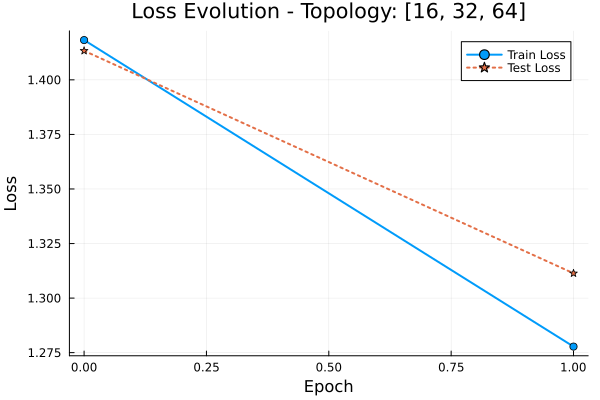

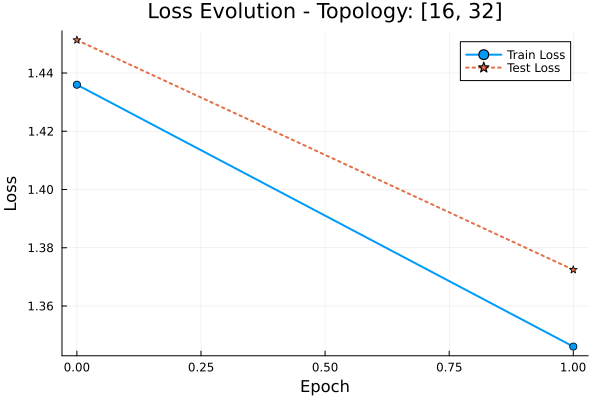

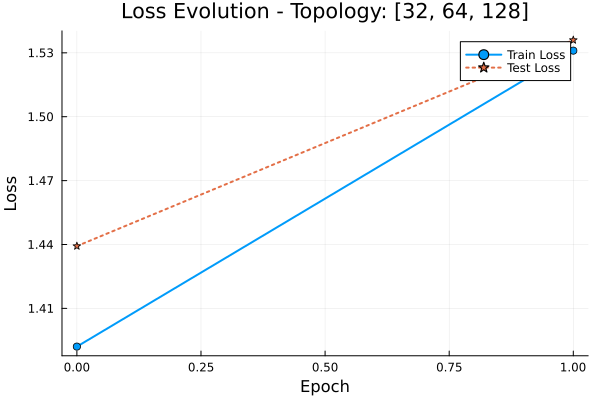

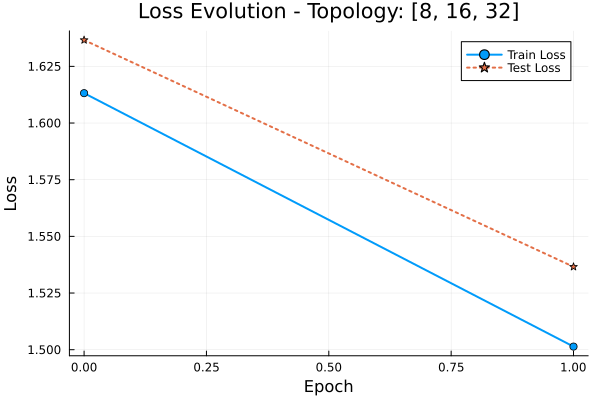

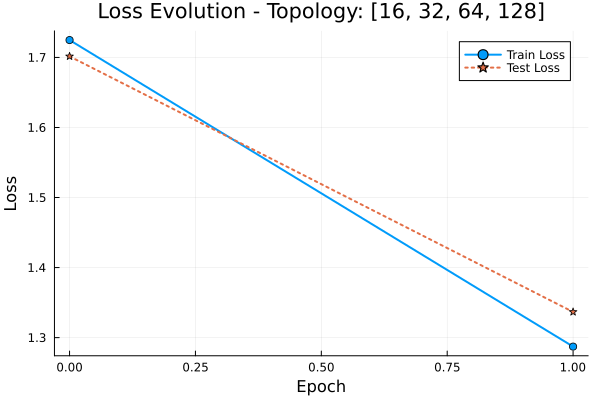

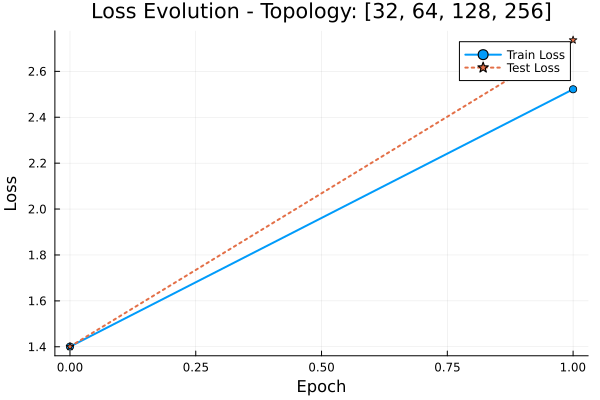

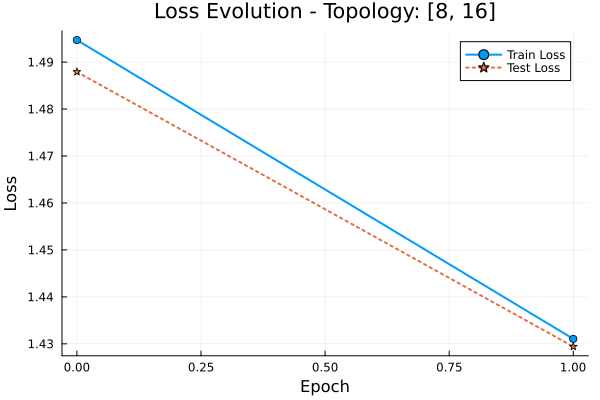

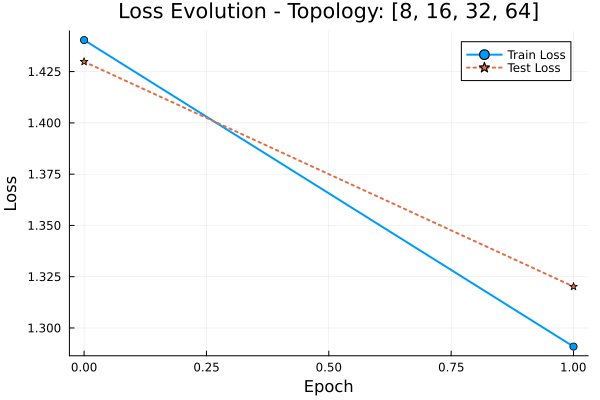

In [7]:
using Flux
using Statistics
using Plots


# --- Safe accuracy function ---
accuracy_score(pred::Vector{Int}, truth::Vector{Int}) = mean(pred .== truth)
accuracy = accuracy_score  # alias so trainClassANN can call accuracy(...)

# Alias for Flux losses
const Losses = Flux

architectures = [
    [8, 16],
    [16, 32],
    [8, 16,32],
    [16, 32,64],
    [ 32,64,128],
    [8, 16,32,64],
    [16, 32,64,128],
    [32,64,128,256],
]

# --- Store all results ---
results = Dict{String, Tuple{Vector{Float32}, Vector{Float32}, Vector{Float32}}}()

# Extract unique classes for one-hot encoding
classes = unique(trainingTargets)

for topology in architectures
    println("\nTraining architecture: ", topology)

    # One-hot encode the targets
    trainingTargetsOH = oneHotEncoding(trainingTargets, classes)
    # valTargetsOH      = oneHotEncoding(valTargets, classes)
    testTargetsOH     = oneHotEncoding(testTargets, classes)

    # Train the network
    finalAnn, trainLoss, valLoss, testLoss = trainClassANN(
        topology,
        (trainingInputs, trainingTargetsOH),
        # validationDataset = (valInputs, valTargetsOH),
        testDataset = (testInputs, testTargetsOH),
        maxEpochs = 1,
        learningRate = 0.01,
        showText = true
    )

    results[string(topology)] = (trainLoss, valLoss, testLoss)

    # --- Compute confusion matrix on test set ---
    testOutputs = finalAnn(testInputs')
    testPredictions = classifyOutputs(testOutputs')  # boolean matrix
    cm_metrics = confusionMatrix(testPredictions, testTargetsOH)

    println("\nConfusion matrix for architecture ", topology, ":")
    println(cm_metrics[end])  # last element is the actual confusion matrix
    #println("\ncm_metrics", cm_metrics, ":")
    # --- Pretty print ---
    println("\n================= MODEL PERFORMANCE =================")
    println("Architecture    : ", topology)
    println("Accuracy        : ", round(cm_metrics[1], digits=4))
    println("Error Rate      : ", round(cm_metrics[2], digits=4))
    println("Recall (Sens.)  : ", round(cm_metrics[3], digits=4))
    println("Specificity     : ", round(cm_metrics[4], digits=4))
    println("PPV (Precision) : ", round(cm_metrics[5], digits=4))
    println("NPV             : ", round(cm_metrics[6], digits=4))
    println("F1 Score        : ", round(cm_metrics[7], digits=4))
    println("=====================================================\n")

end

# --- Plotting all losses, one plot per model ---
for (topology, (trainLoss, valLoss, testLoss)) in results
    epochs = 0:length(trainLoss)-1  # include epoch 0

    p = plot(epochs, trainLoss, label="Train Loss", lw=2, marker=:circle)
    
    # if !isempty(valLoss)
    #     plot!(p, epochs, valLoss, label="Validation Loss", lw=2, linestyle=:dash, marker=:diamond)
    # end
    
    if !isempty(testLoss)
        plot!(p, epochs, testLoss, label="Test Loss", lw=2, linestyle=:dot, marker=:star)
    end

    xlabel!("Epoch")
    ylabel!("Loss")
    title!("Loss Evolution - Topology: $(topology)")
    plot!(legend=:topright)
    
    display(p)  # show the plot
end


# SVM/KNN/DT

## Prepare data for SVM/KNN/DT

In [10]:

trainIdx, testIdx = holdOut(N, 0.3)
println("Train indices: ", length(trainIdx))
println("Test indices: ", length(testIdx))
println("df size: ", size(df))

trainingInputs  = inputs[trainIdx, :]
testInputs      = inputs[testIdx, :]

trainingTargets = targets[trainIdx]
testTargets     = targets[testIdx]

println("\n\nFirst 5 targets:")
println(targets[1:5])

println("Training inputs (first 5 rows):")
for i in 1:5
    println(trainingInputs[i, :])
end



println("\n\n=========== Normalizing Inputs ===========")

# Compute normalization parameters from TRAINING set only
normParams = calculateMinMaxNormalizationParameters(trainingInputs)

# Normalize training set IN PLACE
normalizeMinMax!(trainingInputs, normParams)

# Normalize test set in place
#valInputs_normalized = normalizeMinMax(valInputs, normParams)
normalizeMinMax!(testInputs, normParams)


println("\nTraining inputs after normalization (first 5 rows):")
for i in 1:5
    println(trainingInputs[i, :])
end

println("\nTest inputs after normalization (first 5 rows):")
for i in 1:5
    println(testInputs[i, :])
end

# Convert to float32 for Flux compatibility
trainingInputs = Float32.(trainingInputs)
testInputs = Float32.(testInputs)

# Clip values to [0,1] after normalization
testInputs .= clamp.(testInputs, 0f0, 1f0)
testInputs .= clamp.(testInputs, 0f0, 1f0)

# Convert directly to DataFrames for MLJ
train_df = DataFrame(trainingInputs, :auto)
test_df  = DataFrame(testInputs, :auto)

# Values should only fall within [0,1]
@assert(all(minimum(trainingInputs, dims=1) .== 0))
@assert(all(maximum(trainingInputs, dims=1) .== 1))
@assert(all(minimum(testInputs, dims=1) .>= 0))
@assert(all(maximum(testInputs, dims=1) .<= 1))


println("Train inputs range per feature: ", (minimum(trainingInputs, dims=1), maximum(trainingInputs, dims=1)))
println("Test inputs range per feature: ", (minimum(testInputs, dims=1), maximum(testInputs, dims=1)))


Train indices: 3500
Test indices: 1500
df size: (5000, 10)


First 5 targets:
Float32[3.0, 3.0, 3.0, 1.0, 1.0]
Training inputs (first 5 rows):
Float32[33.0, 62.1, 12.9, 30.8, 35.3, 6.5, 2.28, 6.6, 651.0]
Float32[30.0, 62.2, 53.7, 66.4, 25.5, 8.1, 1.26, 6.2, 670.0]
Float32[22.0, 51.1, 26.0, 27.3, 23.0, 8.2, 1.03, 14.4, 384.0]
Float32[20.1, 55.0, 8.5, 10.7, 24.6, 6.3, 1.07, 17.2, 431.0]
Float32[31.7, 52.1, 24.3, 30.1, 15.3, 6.0, 0.91, 13.8, 418.0]


=========== Normalizing Inputs ===========

Training inputs after normalization (first 5 rows):
Float32[0.4247191, 0.2833876, 0.053727612, 0.118456244, 0.4852174, 0.24853228, 0.5309446, 0.18061674, 0.60208064]
Float32[0.35730335, 0.2844734, 0.2236568, 0.25448987, 0.31478262, 0.27984345, 0.19869706, 0.16299558, 0.626788]
Float32[0.17752808, 0.1639522, 0.10828821, 0.10508215, 0.27130437, 0.28180036, 0.12377849, 0.52422905, 0.25487646]
Float32[0.13483146, 0.20629749, 0.035401914, 0.041650742, 0.29913044, 0.24461839, 0.13680783, 0.6475771, 0.3159

In [ ]:
# ==========================================================
# Helper function for training and evaluating a model
# ==========================================================
function train_and_evaluate_nopca(name, model, train_X, train_y, test_X, test_y; verbose=true)
    if verbose
        println("\nNow working with model: $name")
    end

    # ------------------------------------------------------
    # Convert targets to categorical as required by MLJ
    # ------------------------------------------------------
    train_y_cat = categorical(vec(train_y))
    test_y_cat  = categorical(vec(test_y))

    # Train machine
    mach = machine(model, train_X, train_y_cat)
    MLJ.fit!(mach)

    # ------------------------------------------------------
    # Predict
    # ------------------------------------------------------
    ŷ = MLJ.predict(mach, test_X)

    # SAFE universal label extraction:
    # - If UnivariateFinite → extracts mode
    # - If raw categorical labels → preserved
    # - If numeric/string → converted safely
    ŷ_labels = CategoricalArray(ŷ)

    # ------------------------------------------------------
    # Compute metrics
    # ------------------------------------------------------
    accuracy, error_rate, recall, specificity, ppv, npv, f1, cm =
        confusionMatrix(ŷ_labels, test_y_cat)

    if verbose
        println("Model $name accuracy: $(round(accuracy*100, digits=2)) %")
    end

    # Return all metrics
    return accuracy, error_rate, recall, specificity, ppv, npv, f1, cm
end

# SVM

## function printResult

In [11]:
function printResult(model, hyperparams, metrics,class_labels)
    # Unpack metrics returned by confusionMatrix
    accuracy, error_rate, recall, specificity, ppv, npv, f1, cm = metrics

    println("\n=====================================================")
    println(" Model: $model")
    println(" Hyperparameters: $hyperparams")
    println("=====================================================")

    println(rpad(" Accuracy", 25), ": ", round(accuracy, digits=4))
    println(rpad(" Error Rate", 25), ": ", round(error_rate, digits=4))
    println(rpad(" Sensitivity/Recall", 25), ": ", round(recall, digits=4))
    println(rpad(" Specificity", 25), ": ", round(specificity, digits=4))
    println(rpad(" PPV", 25), ": ", round(ppv, digits=4))
    println(rpad(" NPV", 25), ": ", round(npv, digits=4))
    println(rpad(" F1 Score", 25), ": ", round(f1, digits=4))

    println("\nConfusion Matrix:")
    println(cm)
    println("=====================================================\n")
    cm_df = DataFrame(cm, :auto)
    PrettyTables.pretty_table(cm_df; header=class_labels, row_labels=class_labels)
end


printResult (generic function with 1 method)

In [ ]:

# --- Pretty-print confusion matrix ---
function printConfusionMatrix(cm, class_labels=nothing)
    n = size(cm, 1)
    if class_labels === nothing
        class_labels = string.(1:n)  # default labels
    end

    # Header
    print(" " ^ 12)
    for lbl in class_labels
        print(rpad(lbl, 8))
    end
    println()

    # Rows
    for i in 1:n
        print(rpad(class_labels[i], 12))
        for j in 1:n
            print(rpad(cm[i, j], 8))
        end
        println()
    end
end

# --- Updated experiment print function ---
function printExperimentResult(model, hyperparams, results; class_labels=nothing)
    (
        accuracy, error_rate, recall, specificity,
        ppv, npv, f1, cm
    ) = results

    println("\n=====================================================")
    println(" Model: $model")
    println(" Hyperparameters: $hyperparams")
    println("=====================================================")

    println(" Accuracy              : ", round(accuracy, digits=4))
    println(" Error Rate            : ", round(error_rate, digits=4))
    println(" Sensitivity/Recall    : ", round(recall, digits=4))
    println(" Specificity           : ", round(specificity, digits=4))
    println(" PPV                   : ", round(ppv, digits=4))
    println(" NPV                   : ", round(npv, digits=4))
    println(" F1 Score              : ", round(f1, digits=4))

    println("\nConfusion Matrix:")
    #printConfusionMatrix(cm, class_labels)


    # Suppose `cm` is your confusion matrix (Matrix{Int})
    # and `labels` is your vector of category names, e.g.,
    # labels = ["Good", "Hazardous", "Moderate", "Poor"]

    cm_df = DataFrame(cm, :auto)       # Convert matrix to DataFrame
    rename!(cm_df, Symbol.(class_labels))     # Set column names to labels
    cm_df.row_labels = class_labels           # Custom row labels

    # Use PrettyTables to print nicely
    PrettyTables.pretty_table(cm_df; header=class_labels, row_names=class_labels)



    println("=====================================================\n")
end




In [ ]:
#------------------------------------------------
# Experiment Parameters
#------------------------------------------------
svm_search_space = [
    Dict("kernel"=>"linear", "C"=>0.1),
    Dict("kernel"=>"linear", "C"=>1.0),
    Dict("kernel"=>"linear", "C"=>10.0),

    Dict("kernel"=>"rbf", "C"=>1.0, "gamma"=>2.0),
    Dict("kernel"=>"rbf", "C"=>10.0, "gamma"=>0.5),

    Dict("kernel"=>"sigmoid", "C"=>1.0, "gamma"=>1.0),
    Dict("kernel"=>"poly", "C"=>1.0, "degree"=>3, "gamma"=>1.0),
    Dict("kernel"=>"poly", "C"=>5.0, "degree"=>4, "gamma"=>0.5),
]


# ============================
# LOAD SVM Model
# ============================
SVM = @load SVC pkg = LIBSVM

# --- Convert targets to categorical ---
train_y_cat = categorical(vec(trainingTargets))
test_y_cat  = categorical(vec(testTargets))

# Train machine
mach = machine(SVM(), train_df, train_y_cat)
MLJ.fit!(mach)

# ------------------------------------------------------
# Predict
# ------------------------------------------------------
ŷ = MLJ.predict(mach, test_df)
ŷ_labels = CategoricalArray(ŷ)

# ------------------------------------------------------
# Compute metrics
# ------------------------------------------------------
accuracy, error_rate, recall, specificity, ppv, npv, f1, cm =
    confusionMatrix(ŷ_labels, test_y_cat)

verbose = true    
if verbose
    println("Model $name accuracy: $(round(accuracy*100, digits=2)) %")
end



In [ ]:

using CategoricalArrays

function printExperimentResult(model::Symbol, hyperparams::Dict{String, Any}, 
                               metrics::Tuple{Float64, Float64, Float64, Float64, Float64, Float64, Float64, Matrix{Int}}, 
                               class_labels::Vector{String})
    # Unpack metrics
    accuracy, error_rate, sensitivity, specificity, ppv, npv, f1, cm = metrics

    println("\n=====================================================")
    println(" Model: $model")
    println(" Hyperparameters: $hyperparams")
    println("=====================================================")

    println(" Accuracy              : ", round(accuracy, digits=4))
    println(" Error Rate            : ", round(error_rate, digits=4))
    println(" Sensitivity/Recall    : ", round(sensitivity, digits=4))
    println(" Specificity           : ", round(specificity, digits=4))
    println(" PPV                   : ", round(ppv, digits=4))
    println(" NPV                   : ", round(npv, digits=4))
    println(" F1 Score              : ", round(f1, digits=4))

    println("\nConfusion Matrix:")
    # Convert confusion matrix to DataFrame for pretty printing
    cm_df = DataFrame(cm, :auto)
    PrettyTables.pretty_table(cm_df; header=class_labels, row_names=class_labels)
    println("=====================================================")
end


# SVM

In [14]:
using MLJ, LIBSVM, CategoricalArrays, MLJBase, DataFrames

# --- Default hyperparameters ---
default_svm = Dict(
    "gamma"  => 1.0,
    "degree" => Int32(3),
    "coef0"  => 0.0
)

# --- Hyperparameter search space ---
svm_search_space = [
    Dict("kernel"=>"linear",  "C"=>0.1),
    Dict("kernel"=>"linear",  "C"=>1.0),
    Dict("kernel"=>"linear",  "C"=>10.0),
    Dict("kernel"=>"rbf",     "C"=>1.0, "gamma"=>2.0),
    Dict("kernel"=>"rbf",     "C"=>10.0,"gamma"=>0.5),
    Dict("kernel"=>"sigmoid", "C"=>1.0, "gamma"=>1.0),
    Dict("kernel"=>"poly",    "C"=>1.0, "degree"=>3, "gamma"=>1.0),
    Dict("kernel"=>"poly",    "C"=>5.0, "degree"=>4, "gamma"=>0.5),
]

# --- Convert targets ---
train_y_cat = categorical(vec(trainingTargets))
test_y_cat  = categorical(vec(testTargets))

# --- Container for results ---
svm_results = []

# --- Wrap PCA / raw data as DataFrames ---
# Assume train_df and test_df are already prepared DataFrames of features
# e.g., train_df = DataFrame(pca_train, :auto), test_df = DataFrame(pca_test, :auto)

for hp in svm_search_space
    println("\n=== SVM experiment: kernel=$(hp["kernel"]) C=$(hp["C"]) ===")

    # Map string kernels to LIBSVM.Kernel enums
    kernel_enum = hp["kernel"] == "linear"  ? LIBSVM.Kernel.Linear  :
                  hp["kernel"] == "rbf"     ? LIBSVM.Kernel.RadialBasis :
                  hp["kernel"] == "sigmoid" ? LIBSVM.Kernel.Sigmoid :
                  hp["kernel"] == "poly"    ? LIBSVM.Kernel.Polynomial :
                  error("Unsupported kernel: $(hp["kernel"])")

    cost   = Float64(hp["C"])
    gamma  = Float64(get(hp, "gamma", 1.0))
    degree = Int32(get(hp, "degree", 3))
    coef0  = Float64(get(hp, "coef0", 0.0))

    # Load MLJ SVM model
    SVM_model = @load SVC pkg=LIBSVM verbosity=0
    model = SVM_model(
        kernel = kernel_enum,
        cost   = cost,
        gamma  = gamma,
        degree = degree,
        coef0  = coef0
    )

    # --- Train machine ---
    mach = machine(model, train_df, train_y_cat)
    MLJ.fit!(mach)

    # --- Predict ---
    ŷ = MLJ.predict(mach, test_df)
    y_pred = CategoricalArray(ŷ)

    # --- Metrics ---
    # --- Compute metrics using your function ---
    accuracy, error_rate, recall, specificity, ppv, npv, f1, cm =
        confusionMatrix(y_pred, test_y_cat)

    println("Accuracy = ", round(accuracy, digits=4))

    push!(svm_results, (
        model = :SVC,
        hyperparams = hp,
        metrics = (accuracy, error_rate, recall, specificity, ppv, npv, f1, cm)
    ))


end

results = Dict(:SVC => svm_results)
println("\n===== Grid search finished =====")

for entry in results[:SVC]
    printResult(entry.model, entry.hyperparams, entry.metrics,labels)
    #printExperimentResult(:SVC, Dict("C"=>0.1, "kernel"=>"linear"), results, class_labels=labels)
end






=== SVM experiment: kernel=linear C=0.1 ===
Accuracy = 0.92

=== SVM experiment: kernel=linear C=1.0 ===
Accuracy = 0.9333

=== SVM experiment: kernel=linear C=10.0 ===
Accuracy = 0.94

=== SVM experiment: kernel=rbf C=1.0 ===
Accuracy = 0.9407

=== SVM experiment: kernel=rbf C=10.0 ===
Accuracy = 0.9433

=== SVM experiment: kernel=sigmoid C=1.0 ===
Accuracy = 0.4867

=== SVM experiment: kernel=poly C=1.0 ===
Accuracy = 0.9313

=== SVM experiment: kernel=poly C=5.0 ===
Accuracy = 0.9273

===== Grid search finished =====

 Model: SVC
 Hyperparameters: Dict{String, Any}("C" => 0.1, "kernel" => "linear")
 Accuracy                : 0.92
 Error Rate              : 0.08
 Sensitivity/Recall      : 0.92
 Specificity             : 0.9722
 PPV                     : 0.9225
 NPV                     : 0.9824
 F1 Score                : 0.9179

Confusion Matrix:
[423 0 9 7; 0 106 0 53; 1 0 596 0; 46 3 1 255]

┌───────────┬──────┬───────────┬──────────┬──────┐
│           │ Good │ Hazardous │ Moderat

# DT

In [15]:
# ============================
# LOAD DecisionTree Model
# ============================

############# 3. DECISION TREES (6 depths) #############
default_dt = Dict(
    "rng" => Random.MersenneTwister(1)
)

dt_search_space = [
    Dict("max_depth"=>2),
    Dict("max_depth"=>3),
    Dict("max_depth"=>4),
    Dict("max_depth"=>5),
    Dict("max_depth"=>6),
    Dict("max_depth"=>8)
]



# --- Convert targets ---

# --- Container for results ---
dt_results = []

# --- Wrap PCA / raw data as DataFrames ---
# Assume train_df and test_df are already prepared DataFrames of features

# ----------------------------
# DECISION TREE GRID SEARCH
# ----------------------------
for hp in dt_search_space
    println("\n=== Decision Tree experiment: max_depth=$(hp["max_depth"]) ===")
    
    # Merge default hyperparameters with current hp
    full_hp = merge(default_dt, hp)
    
    # Load DecisionTreeClassifier
    DT_model = @load DecisionTreeClassifier pkg=DecisionTree verbosity=0
    model = DT_model(
        max_depth = full_hp["max_depth"],
        rng       = full_hp["rng"]
    )
    
    # --- Train machine ---
    mach = machine(model, train_df, train_y_cat)
    MLJ.fit!(mach)
    
    # --- Predict ---
    ŷ = MLJ.predict(mach, test_df)
    y_pred = CategoricalArray(mode.(ŷ))  # convert MLJ probabilistic predictions to class labels

    
    # --- Compute metrics ---
    accuracy, error_rate, recall, specificity, ppv, npv, f1, cm =
        confusionMatrix(y_pred, test_y_cat)
    
    println("Accuracy = ", round(accuracy, digits=4))
    
    push!(dt_results, (
        model = :DecisionTree,
        hyperparams = hp,
        metrics = (accuracy, error_rate, recall, specificity, ppv, npv, f1, cm)
    ))
end

# Store results in dict
results[:DecisionTree] = dt_results
println("\n===== Grid search finished =====")

# ----------------------------
# Print all results
# ----------------------------
for entry in results[:DecisionTree]
    printResult(entry.model, entry.hyperparams, entry.metrics, labels)
end




=== Decision Tree experiment: max_depth=2 ===
Accuracy = 0.8193

=== Decision Tree experiment: max_depth=3 ===
Accuracy = 0.886

=== Decision Tree experiment: max_depth=4 ===
Accuracy = 0.9027

=== Decision Tree experiment: max_depth=5 ===
Accuracy = 0.906

=== Decision Tree experiment: max_depth=6 ===
Accuracy = 0.92

=== Decision Tree experiment: max_depth=8 ===
Accuracy = 0.928

===== Grid search finished =====

 Model: DecisionTree
 Hyperparameters: Dict("max_depth" => 2)
 Accuracy                : 0.8193
 Error Rate              : 0.1807
 Sensitivity/Recall      : 0.8193
 Specificity             : 0.9442
 PPV                     : 0.7507
 NPV                     : 0.9638
 F1 Score                : 0.7813

Confusion Matrix:
[412 0 2 25; 2 0 0 157; 5 0 592 0; 80 0 0 225]

┌───────────┬──────┬───────────┬──────────┬──────┐
│           │ Good │ Hazardous │ Moderate │ Poor │
├───────────┼──────┼───────────┼──────────┼──────┤
│      Good │  412 │         0 │        2 │   25 │
│ Hazardo

# KNN

In [16]:
############# 4. kNN (6 values) #############
knn_search_space = [
    Dict("K"=>1),
    Dict("K"=>3),
    Dict("K"=>5),
    Dict("K"=>7),
    Dict("K"=>9),
    Dict("K"=>11)
]

# --- Convert targets ---
train_y_cat = categorical(vec(trainingTargets))
test_y_cat  = categorical(vec(testTargets))

# --- Container for results ---
knn_results = []

# --- kNN hyperparameter search space ---
knn_search_space = [
    Dict("K"=>1),
    Dict("K"=>3),
    Dict("K"=>5),
    Dict("K"=>7),
    Dict("K"=>9),
    Dict("K"=>11)
]

# --- Loop over K values ---
KNN_model_type = @load KNNClassifier pkg=NearestNeighborModels verbosity=0

for hp in knn_search_space
    println("\n=== kNN experiment: K=$(hp["K"]) ===")
    
    K = Int(hp["K"])
    
    # Load MLJ KNN model
    model = KNN_model_type(K=K)
    
    # --- Train machine ---
    mach = machine(model, train_df, train_y_cat)
    MLJ.fit!(mach)
    
    # --- Predict ---
    ŷ = MLJ.predict(mach, test_df)              # probabilistic predictions
    y_pred = CategoricalArray(mode.(ŷ))         # convert to class labels
    
    # --- Compute metrics ---
    accuracy, error_rate, recall, specificity, ppv, npv, f1, cm =
        confusionMatrix(y_pred, test_y_cat)
    
    println("Accuracy = ", round(accuracy, digits=4))
    
    # --- Save results ---
    push!(knn_results, (
        model = :kNN,
        hyperparams = hp,
        metrics = (accuracy, error_rate, recall, specificity, ppv, npv, f1, cm)
    ))
end

# --- Store all results ---
results[:kNN] = knn_results

# --- Print results ---
for entry in results[:kNN]
    printResult(entry.model, entry.hyperparams, entry.metrics, labels)
end



=== kNN experiment: K=1 ===
Accuracy = 0.912

=== kNN experiment: K=3 ===
Accuracy = 0.9267

=== kNN experiment: K=5 ===
Accuracy = 0.93

=== kNN experiment: K=7 ===
Accuracy = 0.9307

=== kNN experiment: K=9 ===
Accuracy = 0.928

=== kNN experiment: K=11 ===
Accuracy = 0.9247

 Model: kNN
 Hyperparameters: Dict("K" => 1)
 Accuracy                : 0.912
 Error Rate              : 0.088
 Sensitivity/Recall      : 0.912
 Specificity             : 0.9726
 PPV                     : 0.9103
 NPV                     : 0.9788
 F1 Score                : 0.9101

Confusion Matrix:
[425 0 5 9; 0 118 0 41; 4 0 593 0; 50 23 0 232]

┌───────────┬──────┬───────────┬──────────┬──────┐
│           │ Good │ Hazardous │ Moderate │ Poor │
├───────────┼──────┼───────────┼──────────┼──────┤
│      Good │  425 │         0 │        5 │    9 │
│ Hazardous │    0 │       118 │        0 │   41 │
│  Moderate │    4 │         0 │      593 │    0 │
│      Poor │   50 │        23 │        0 │  232 │
└───────────┴──

In [ ]:


# ============================
# LOAD MODELS
# ============================
SVM        = @load SVC pkg = LIBSVM
DecisionTree = @load DecisionTreeClassifier pkg = DecisionTree verbosity=0
KNN        = @load KNNClassifier pkg = NearestNeighborModels verbosity=0

# ============================
# Function: Run models WITHOUT PCA
# ============================
function run_models_no_pca(trainingInputs, trainingTargetsCat,
                           testInputs, testTargetsCat)

    results = DataFrame(
        model   = String[],
        pca_dim = String[],       # use string label for pivot
        accuracy = Float64[]
    )

    println("\n===== Running models WITHOUT PCA =====")

    # Convert directly to DataFrames for MLJ
    train_df = DataFrame(trainingInputs, :auto)
    test_df  = DataFrame(testInputs, :auto)

    # Models to run
    models_dict = Dict(
        "SVM" => SVM(),
        "DT"  => DecisionTree(max_depth = 4),
        "KNN" => KNN()
    )

    # Train + evaluate
    for (name, model) in models_dict
        acc = train_and_evaluate(
            name, model,
            train_df, trainingTargetsCat,
            test_df,  testTargetsCat;
            verbose = false
        )
        push!(results, (name, "Raw", acc))
    end

    return results
end

# ============================
# RUN MODELS WITHOUT PCA
# ============================
# --- Convert targets to categorical ---
trainingTargetsCat = categorical(trainingTargets)
#valTargetsCat      = categorical(valTargets)
testTargetsCat      = categorical(testTargets)

raw_no_pca_results = run_models_no_pca(
    trainingInputs, trainingTargetsCat,
    testInputs, testTargetsCat
)

println("\n========== RAW RESULTS (NO PCA) ==========")
println(raw_no_pca_results)

# Pivot: rows=model, columns=pca_dim (here only "Raw"), values=accuracy
final_no_pca_report = unstack(raw_no_pca_results, :model, :pca_dim, :accuracy)

println("\n========== FINAL REPORT (NO PCA) ==========")
println(final_no_pca_report)
println("====================================================")
